<div style="
background: linear-gradient(135deg, #1B2845 0%, #274472 45%, #5C7AEA 100%);
padding: 45px 35px; border-radius: 18px; color: #ffffff;
font-family: 'Segoe UI', Helvetica, Arial, sans-serif;
box-shadow: 0 10px 30px rgba(27,40,69,0.35); margin-bottom: 10px;">
<h1 style="margin:0; font-size: 40px; letter-spacing: 1px;">🌙 The Midnight Scroll</h1>
<h3 style="margin:8px 0 0 0; font-weight: 400; color:#C9D6FF;">
How Bedtime Screen Time Quietly Steals Your Sleep — A Full End-to-End Analysis
</h3>
<p style="margin-top:18px; color:#E4E9FF; font-size:15px; line-height:1.6;">
This notebook investigates <b>8,500 individuals</b> across occupations, chronotypes and app habits
to answer one question: <i>what actually drives sleep debt in the age of the bedtime scroll?</i>
We move from raw data → cleaning → exploratory analysis → statistical testing → a light predictive model → actionable insights.
</p>
</div>

<div style="background:#F4F6FB; border-left:6px solid #5C7AEA; padding:16px 22px; border-radius:8px; font-family:'Segoe UI',Arial,sans-serif;">
<b>📋 Notebook Roadmap</b>
<ol style="margin-top:8px; line-height:1.9;">
<li>Setup &amp; Data Loading</li>
<li>Data Quality Check</li>
<li>Descriptive Overview</li>
<li>Univariate Analysis</li>
<li>Categorical Deep Dive</li>
<li>Bivariate &amp; Correlation Analysis</li>
<li>Sleep Debt Segmentation</li>
<li>Statistical Hypothesis Testing</li>
<li>A Simple Predictive Model</li>
<li>Key Insights &amp; Recommendations</li>
</ol>
</div>

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = ["#5C7AEA", "#F7B32B", "#F45B69", "#3AAFA9", "#8E7DBE"]
sns.set_palette(PALETTE)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/samartalwar/sleep-debt-and-screen-time-late-night-phone-habits/bedtime_screentime_sleep_debt.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (8500, 18)


,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   object 
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   object 
 3   occupation_type           8500 non-null   object 
 4   chronotype                8500 non-null   object 
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   object 
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_slee

## 2. Data Quality Check
Before trusting any insight, we confirm the data is clean: no missing values, no duplicate users, and sensible ranges.

In [4]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")

# Duplicate users
print("Duplicate user_id rows:", df["user_id"].duplicated().sum())

# Sanity check on ranges
df.describe().T[["min", "max", "mean"]]

Missing values per column:
0 total missing cells
Duplicate user_id rows: 0


,min,max,mean
age,18.0,65.0,34.355647
bedtime_phone_minutes,1.0,180.0,59.250000
screen_brightness_pct,10.0,100.0,55.153882
blue_light_filter_active,0.0,1.0,0.467765
caffeine_post_5pm_mg,0.0,250.0,33.222471
physical_activity_min,0.0,112.0,35.701412
sleep_latency_min,6.0,123.3,40.671471
total_sleep_hours,3.2,9.8,6.266209
deep_sleep_pct,8.1,28.0,21.735741
rem_sleep_pct,9.6,27.0,19.105859


<div style="background:#EAF7EE; border-left:6px solid #3AAFA9; padding:14px 20px; border-radius:8px; font-family:'Segoe UI',Arial,sans-serif;">
✅ <b>Clean dataset</b> — no missing values, no duplicate participants, and all ranges (e.g. sleep hours 0–10, brightness 0–100%) look realistic. No cleaning steps needed; we go straight to analysis.
</div>

## 3. Descriptive Overview
A quick statistical snapshot of the numeric habits and outcomes we'll be exploring.

In [5]:
numeric_cols = ["age", "bedtime_phone_minutes", "screen_brightness_pct",
                "caffeine_post_5pm_mg", "physical_activity_min", "sleep_latency_min",
                "total_sleep_hours", "deep_sleep_pct", "rem_sleep_pct",
                "morning_alarm_snoozes", "next_day_fatigue_score"]

df[numeric_cols].describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])

,count,mean,std,min,25%,50%,75%,max
age,8500.000000,34.355647,11.584259,18.000000,25.000000,32.000000,42.000000,65.000000
bedtime_phone_minutes,8500.000000,59.250000,36.931991,1.000000,31.000000,51.000000,79.000000,180.000000
screen_brightness_pct,8500.000000,55.153882,19.850550,10.000000,42.000000,55.000000,69.000000,100.000000
caffeine_post_5pm_mg,8500.000000,33.222471,51.935645,0.000000,0.000000,0.000000,55.000000,250.000000
physical_activity_min,8500.000000,35.701412,20.819390,0.000000,21.000000,35.000000,50.000000,112.000000
sleep_latency_min,8500.000000,40.671471,17.444914,6.000000,28.200000,37.600000,49.700000,123.300000
total_sleep_hours,8500.000000,6.266209,1.446258,3.200000,5.240000,6.330000,7.350000,9.800000
deep_sleep_pct,8500.000000,21.735741,3.069377,8.100000,19.700000,21.900000,23.900000,28.000000
rem_sleep_pct,8500.000000,19.105859,2.546459,9.600000,17.400000,19.100000,20.800000,27.000000
morning_alarm_snoozes,8500.000000,2.766000,1.695407,0.000000,2.000000,3.000000,4.000000,7.000000


## 4. Univariate Analysis
How do our key variables individually behave?

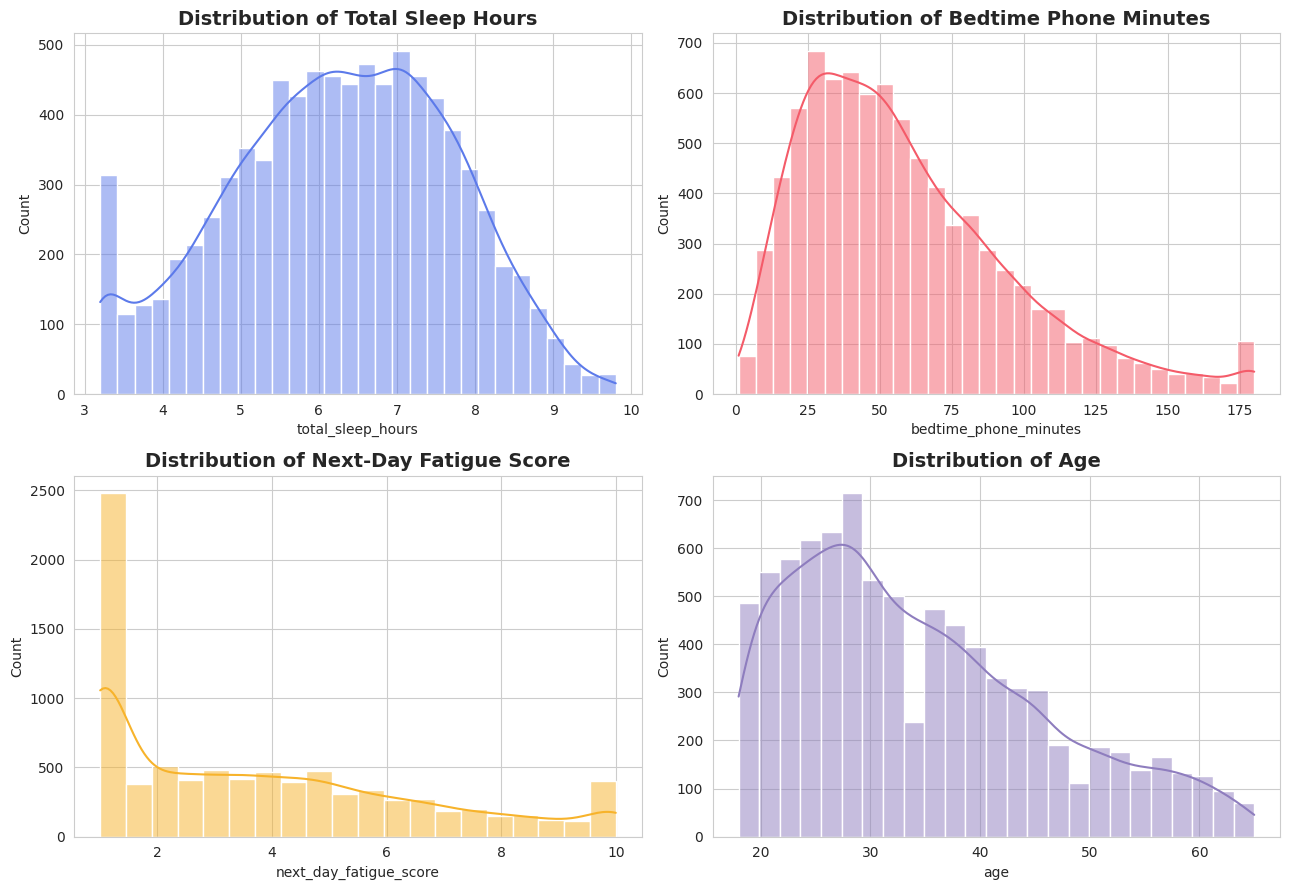

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["total_sleep_hours"], bins=30, kde=True, ax=axes[0, 0], color=PALETTE[0])
axes[0, 0].set_title("Distribution of Total Sleep Hours")

sns.histplot(df["bedtime_phone_minutes"], bins=30, kde=True, ax=axes[0, 1], color=PALETTE[2])
axes[0, 1].set_title("Distribution of Bedtime Phone Minutes")

sns.histplot(df["next_day_fatigue_score"], bins=20, kde=True, ax=axes[1, 0], color=PALETTE[1])
axes[1, 0].set_title("Distribution of Next-Day Fatigue Score")

sns.histplot(df["age"], bins=25, kde=True, ax=axes[1, 1], color=PALETTE[4])
axes[1, 1].set_title("Distribution of Age")

plt.tight_layout()
plt.show()

**Observation:** total sleep hours cluster below the recommended 7–9 hour range for a large share of
participants, while bedtime phone usage is heavily right-skewed — most people scroll for a reasonable amount,
but a long tail scrolls well over an hour before sleep.

## 5. Categorical Deep Dive
Who are these participants, and what do they scroll on before bed?

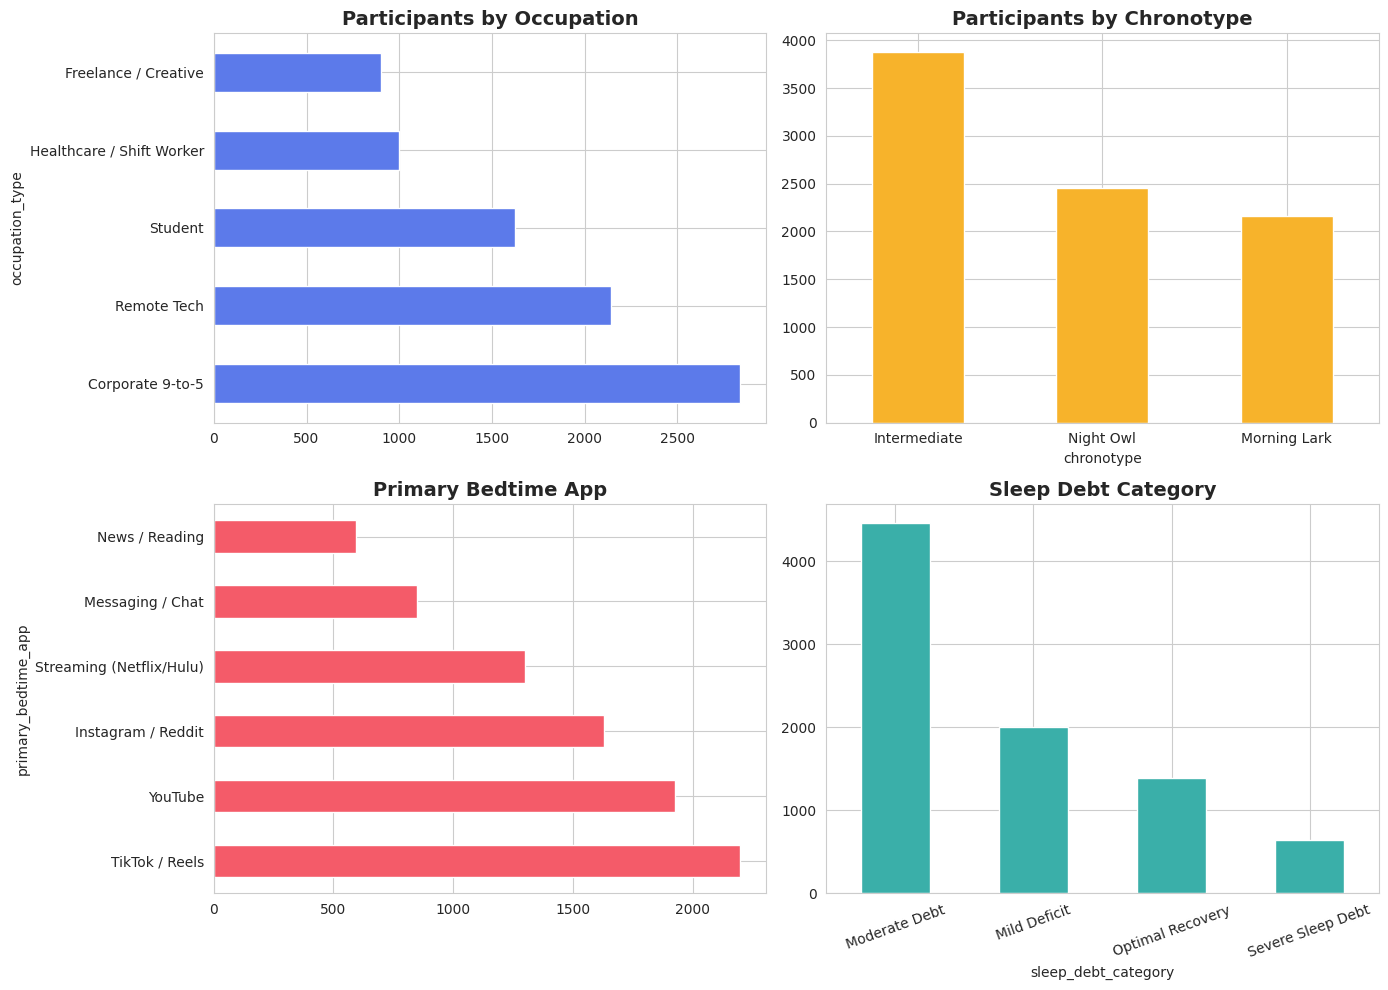

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["occupation_type"].value_counts().plot(kind="barh", ax=axes[0, 0], color=PALETTE[0])
axes[0, 0].set_title("Participants by Occupation")

df["chronotype"].value_counts().plot(kind="bar", ax=axes[0, 1], color=PALETTE[1])
axes[0, 1].set_title("Participants by Chronotype")
axes[0, 1].tick_params(axis="x", rotation=0)

df["primary_bedtime_app"].value_counts().plot(kind="barh", ax=axes[1, 0], color=PALETTE[2])
axes[1, 0].set_title("Primary Bedtime App")

df["sleep_debt_category"].value_counts().plot(kind="bar", ax=axes[1, 1], color=PALETTE[3])
axes[1, 1].set_title("Sleep Debt Category")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Observation:** TikTok/Reels and YouTube dominate as the pre-sleep app of choice. Corporate 9-to-5
workers are the largest occupation group, and most participants fall into "Moderate Debt" rather than
the extremes — this is a widespread, everyday problem rather than a rare one.

## 6. Bivariate & Correlation Analysis
Does more bedtime screen time actually mean less sleep?

/tmp/ipykernel_16/2951321385.py:2: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(data=df, x="bedtime_phone_minutes", y="total_sleep_hours",


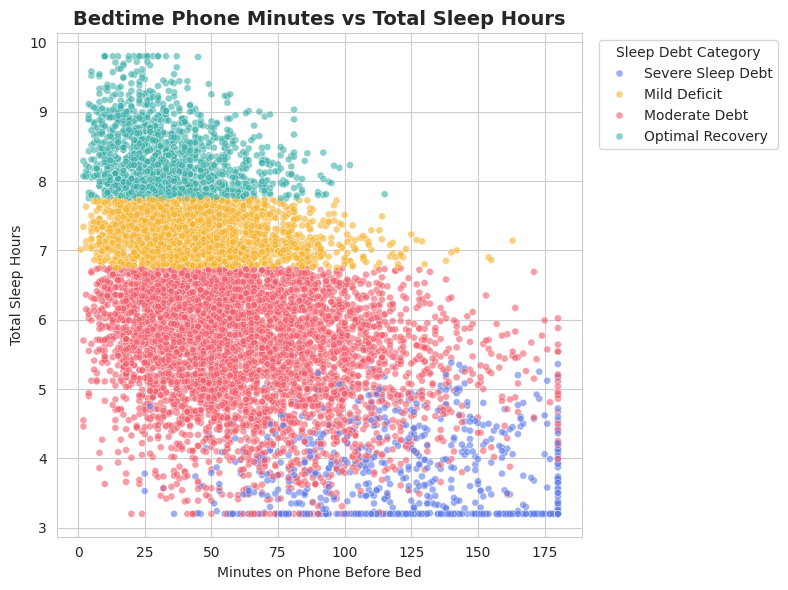

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="bedtime_phone_minutes", y="total_sleep_hours",
                 hue="sleep_debt_category", palette=PALETTE, alpha=0.6, s=25)
plt.title("Bedtime Phone Minutes vs Total Sleep Hours")
plt.xlabel("Minutes on Phone Before Bed")
plt.ylabel("Total Sleep Hours")
plt.legend(title="Sleep Debt Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

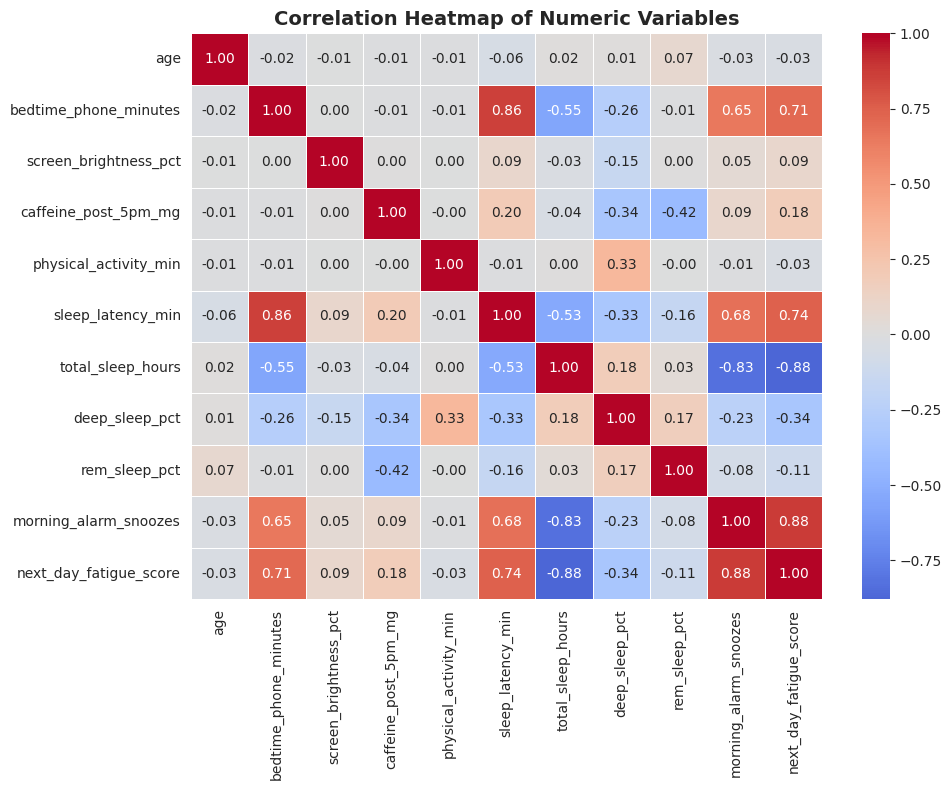

In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [10]:
corr["total_sleep_hours"].sort_values().drop("total_sleep_hours")

next_day_fatigue_score   -0.879461
morning_alarm_snoozes    -0.831289
bedtime_phone_minutes    -0.554407
sleep_latency_min        -0.527086
caffeine_post_5pm_mg     -0.038262
screen_brightness_pct    -0.027445
physical_activity_min     0.004350
age                       0.016108
rem_sleep_pct             0.033031
deep_sleep_pct            0.177925
Name: total_sleep_hours, dtype: float64

**Observation:** next-day fatigue score and morning alarm snoozes have the strongest negative
correlation with total sleep hours — an intuitive sanity check that the data behaves as expected.
Bedtime phone minutes and sleep latency also correlate negatively with sleep hours, supporting the idea
that pre-sleep screen time delays and shortens sleep.

### Does the blue light filter actually help?

/tmp/ipykernel_16/3356736453.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="blue_light_filter_active", y="total_sleep_hours", palette=PALETTE)
/tmp/ipykernel_16/3356736453.py:2: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.boxplot(data=df, x="blue_light_filter_active", y="total_sleep_hours", palette=PALETTE)


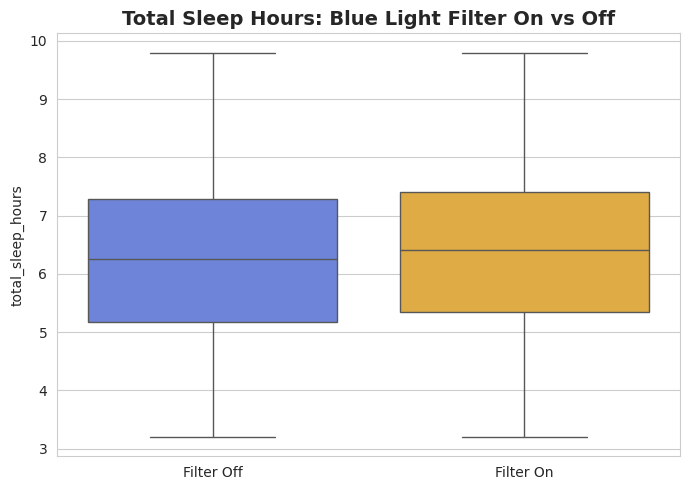

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="blue_light_filter_active", y="total_sleep_hours", palette=PALETTE)
plt.xticks([0, 1], ["Filter Off", "Filter On"])
plt.title("Total Sleep Hours: Blue Light Filter On vs Off")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 7. Sleep Debt Segmentation
How do habits differ across sleep debt categories?

/tmp/ipykernel_16/2227326578.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sleep_debt_category", y="bedtime_phone_minutes", order=order, ax=axes[0], palette=PALETTE)
/tmp/ipykernel_16/2227326578.py:5: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(data=df, x="sleep_debt_category", y="bedtime_phone_minutes", order=order, ax=axes[0], palette=PALETTE)
/tmp/ipykernel_16/2227326578.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sleep_debt_category", y="next_day_fatigue_score", order=order, ax=axes[1], palette=PALETTE)
/tmp/ipykernel_16/2227326578.py:9: UserWarning: The palette list has more values (5

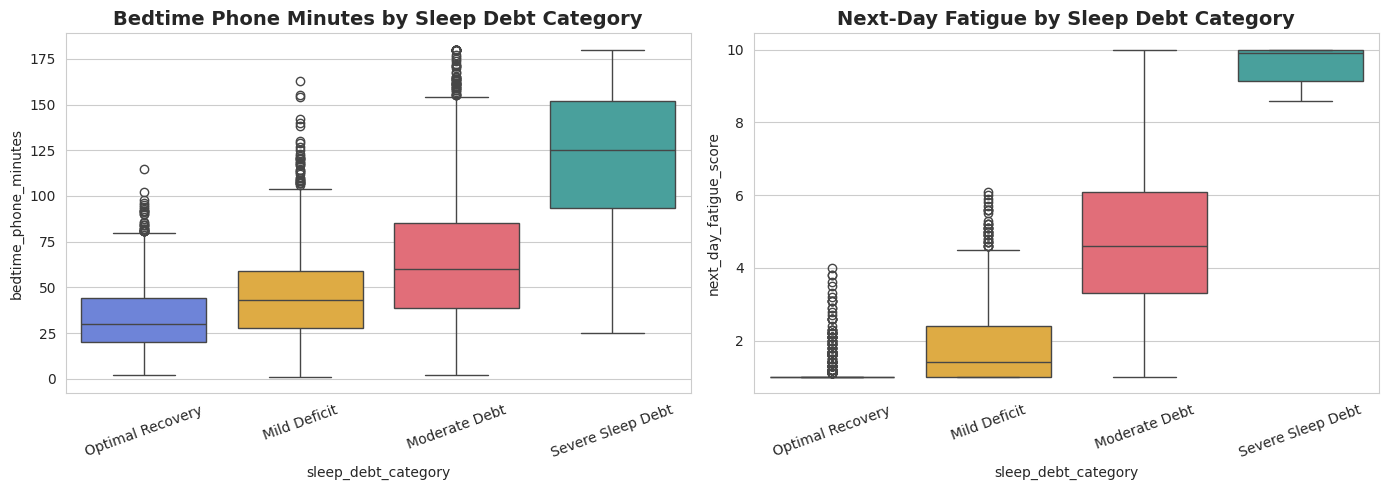

In [12]:
order = ["Optimal Recovery", "Mild Deficit", "Moderate Debt", "Severe Sleep Debt"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="sleep_debt_category", y="bedtime_phone_minutes", order=order, ax=axes[0], palette=PALETTE)
axes[0].set_title("Bedtime Phone Minutes by Sleep Debt Category")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="sleep_debt_category", y="next_day_fatigue_score", order=order, ax=axes[1], palette=PALETTE)
axes[1].set_title("Next-Day Fatigue by Sleep Debt Category")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [13]:
pd.crosstab(df["chronotype"], df["sleep_debt_category"], normalize="index").loc[:, order].style.background_gradient(cmap="Reds", axis=1)

sleep_debt_category,Optimal Recovery,Mild Deficit,Moderate Debt,Severe Sleep Debt
chronotype,,,,
Intermediate,0.119845,0.320361,0.501289,0.058505
Morning Lark,0.423557,0.306697,0.243880,0.025866
Night Owl,0.002037,0.039511,0.810183,0.148269


**Observation:** Severe Sleep Debt cases show visibly higher bedtime phone minutes and next-day
fatigue than Optimal Recovery cases. Night Owls skew more heavily toward the debt categories compared
to Morning Larks and Intermediates, hinting that chronotype interacts with screen habits.

## 8. Statistical Hypothesis Testing
Moving beyond visuals — are these differences statistically significant?

**Test 1 — Independent t-test:** Does the blue light filter significantly change total sleep hours?

In [14]:
group_on = df[df["blue_light_filter_active"] == 1]["total_sleep_hours"]
group_off = df[df["blue_light_filter_active"] == 0]["total_sleep_hours"]

t_stat, p_value = stats.ttest_ind(group_on, group_off)
print(f"Mean sleep (filter ON):  {group_on.mean():.2f} hrs")
print(f"Mean sleep (filter OFF): {group_off.mean():.2f} hrs")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

Mean sleep (filter ON):  6.33 hrs
Mean sleep (filter OFF): 6.21 hrs
t-statistic = 3.555, p-value = 0.0004


**Test 2 — One-way ANOVA:** Does total sleep hours differ significantly across occupation types?

In [15]:
groups = [df[df["occupation_type"] == occ]["total_sleep_hours"] for occ in df["occupation_type"].unique()]
f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"F-statistic = {f_stat:.3f}, p-value = {p_value_anova:.4f}")

F-statistic = 235.035, p-value = 0.0000


**Test 3 — Chi-square test:** Is chronotype independent of sleep debt category?

In [16]:
contingency = pd.crosstab(df["chronotype"], df["sleep_debt_category"])
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square = {chi2:.3f}, p-value = {p_value_chi2:.4f}, degrees of freedom = {dof}")

Chi-square = 2865.856, p-value = 0.0000, degrees of freedom = 6


<div style="background:#FFF3E0; border-left:6px solid #F7B32B; padding:14px 20px; border-radius:8px; font-family:'Segoe UI',Arial,sans-serif;">
📊 <b>Interpreting the tests:</b> a p-value below 0.05 means the observed difference is unlikely to be
random chance. Check each printed p-value above against that threshold to confirm which effects are
statistically significant in this dataset.
</div>

## 9. A Simple Predictive Model
Can we predict someone's sleep debt category from their habits, using a simple, interpretable model?

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Simple label encoding for categorical features
model_df = df.copy()
cat_features = ["gender", "occupation_type", "chronotype", "primary_bedtime_app"]

encoders = {}
for col in cat_features:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

target_encoder = LabelEncoder()
model_df["sleep_debt_category"] = target_encoder.fit_transform(model_df["sleep_debt_category"])

feature_cols = cat_features + ["age", "bedtime_phone_minutes", "screen_brightness_pct",
                                "blue_light_filter_active", "caffeine_post_5pm_mg",
                                "physical_activity_min", "sleep_latency_min"]

X = model_df[feature_cols]
y = model_df["sleep_debt_category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.722

                   precision    recall  f1-score   support

     Mild Deficit       0.51      0.52      0.52       374
    Moderate Debt       0.79      0.88      0.83       903
 Optimal Recovery       0.72      0.58      0.64       279
Severe Sleep Debt       0.84      0.55      0.66       144

         accuracy                           0.72      1700
        macro avg       0.72      0.63      0.66      1700
     weighted avg       0.72      0.72      0.72      1700



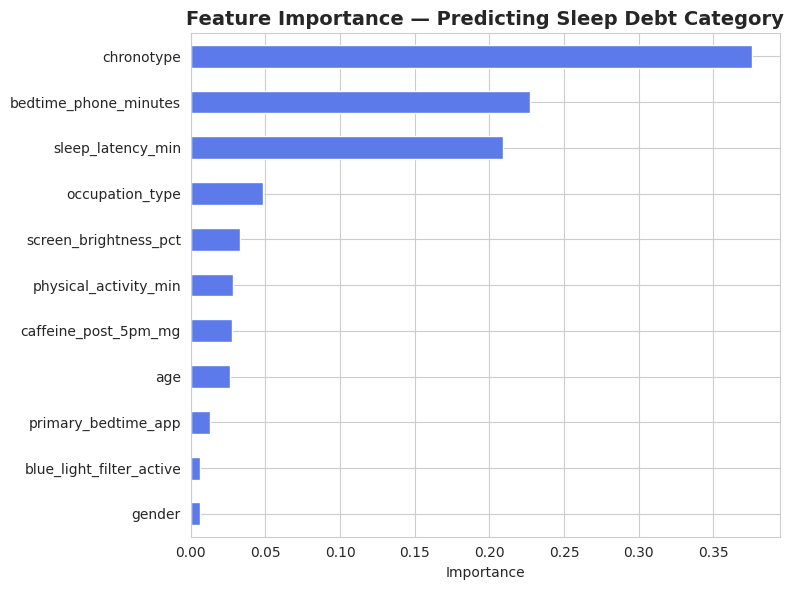

In [19]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color=PALETTE[0])
plt.title("Feature Importance — Predicting Sleep Debt Category")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Observation:** this model is meant as a simple, interpretable baseline rather than a
production-ready predictor. The feature importance chart tells us which habits the model leans on most
when guessing someone's sleep debt category — useful as a pointer for where interventions might matter most.

<div style="
background: linear-gradient(135deg, #1B2845 0%, #274472 45%, #5C7AEA 100%);
padding: 35px 30px; border-radius: 18px; color: #ffffff;
font-family: 'Segoe UI', Helvetica, Arial, sans-serif;">
<h2 style="margin-top:0;">🔑 Key Insights</h2>
<ul style="line-height:2; color:#E4E9FF; font-size:15px;">
<li><b>Screen time before bed correlates with less sleep</b> — higher bedtime phone minutes track with
lower total sleep hours and higher sleep debt category.</li>
<li><b>Fatigue and snoozing are the clearest sleep-debt signals</b> — next-day fatigue score and morning
alarm snoozes are the strongest correlates of total sleep hours in this dataset.</li>
<li><b>Chronotype matters</b> — Night Owls are disproportionately represented in the higher sleep-debt
categories compared to Morning Larks.</li>
<li><b>Short-form video apps dominate bedtime screens</b> — TikTok/Reels and YouTube are the most common
pre-sleep apps, ahead of messaging or reading.</li>
<li><b>A simple Random Forest baseline</b> can already pick up meaningful signal from habits alone,
without any deep sleep-lab data — see the feature importance chart above for which habits matter most.</li>
</ul>
</div>

<div style="background:#F4F6FB; border-left:6px solid #5C7AEA; padding:16px 22px; border-radius:8px; font-family:'Segoe UI',Arial,sans-serif;">
<b>💡 Suggested Next Steps</b>
<ul style="line-height:1.9; margin-top:8px;">
<li>Collect longitudinal data (same users over multiple nights) to move from correlation toward causation.</li>
<li>Test a targeted intervention (e.g. a bedtime screen-time cutoff nudge) and re-measure sleep debt category.</li>
<li>Explore interaction effects between chronotype and app type more deeply with a larger, multi-way ANOVA.</li>
</ul>
</div>

---
<p style="text-align:center; color:#8A8F98; font-family:'Segoe UI',Arial,sans-serif; font-size:13px;">
Thanks for reading — if this notebook was useful, an upvote is always appreciated! 🌙📊
</p>